<a href="https://colab.research.google.com/github/yorsyd/LearnData/blob/main/Tensorflow_org_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation

## Install and import module

In [12]:
# # Install the most re version of TensorFlow to use the improved
# # masking support for `tf.keras.layers.MultiHeadAttention`.
# !apt install --allow-change-held-packages libcudnn8=8.1.0.77-1+cuda11.2
# !pip uninstall -y -q tensorflow keras tensorflow-estimator tensorflow-text
# !pip install protobuf~=3.20.3
# !pip install -q tensorflow_datasets
# !pip install -q -U tensorflow-text tensorflow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package libcudnn8
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.1 requires protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.5 MB/s eta 0:00:00


In [1]:
import logging
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow_datasets as tfds
import tensorflow as tf

import tensorflow_text

## path data

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
path = f'/content/drive/MyDrive/skripsi/Yoga Rusydi Arifin/PROGRAM/Dummy/korpus.csv'

In [4]:
df = pd.read_csv(path)
df.head()

,Unnamed: 0,id,bkl
0,0,Bunga dihalaman rumah dibersihkan semua oleh t...,Bungo dilaman rumah di babat galo dekek tukang...
1,1,Bapak ini sangat suka dengan sayur perut sapi,Gaek lanang iko suko nian gulai sapi babat
2,2,Dia menikahkan anak nya sangat besar-besaran,Nyo nikahi anak nyo berarat-arat nian
3,3,Sakitnya sekarang sudah bertambah parah,Sakitnyo kini lah bertambah arat
4,4,Sudah sebesar ini saya belum juga menghapal pe...,La segedang iko ambo belum jugo apal perkalian


In [5]:
src_col = 'id'
dst_col = 'bkl'

# Preprocessing

In [6]:
import pandas as pd
import re
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from sklearn.model_selection import train_test_split

# Fungsi pembersihan teks
def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zA-Zà-žÀ-Ž0-9\s']", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

# Fungsi memuat dan membersihkan data
def load_clean_split_data(csv_path, source_col="id", target_col="bkl", test_size=0.1):
    df = pd.read_csv(csv_path)
    df = df[[source_col, target_col]].dropna().drop_duplicates()
    df[source_col] = df[source_col].apply(clean_text)
    df[target_col] = df[target_col].apply(clean_text)
    return train_test_split(df[source_col], df[target_col], test_size=test_size, random_state=42)

# Fungsi membuat vectorizer/tokenizer
def tokenizers(train_src, train_tgt, max_tokens=10000, seq_len=40):
    # Tambahkan token khusus <sos> dan <eos> ke target
    train_tgt = train_tgt.apply(lambda x: '[SOS] ' + x + ' [EOS]')

    # Buat vectorizer
    source_vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=seq_len
    )

    target_vectorizer = TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=seq_len + 2  # untuk [SOS] dan [EOS]
    )

    source_vectorizer.adapt(train_src)
    target_vectorizer.adapt(train_tgt)

    return source_vectorizer, target_vectorizer


In [7]:
def format_dataset(src, tgt, source_vectorizer, target_vectorizer):
    """Tokenisasi dan format input–target untuk model Transformer."""
    src_vectorized = source_vectorizer(src)
    tgt = tf.strings.join(['[SOS] ', tgt, ' [EOS]'])  # Tambah token khusus
    tgt_vectorized = target_vectorizer(tgt)

    encoder_input = src_vectorized  # Input untuk encoder
    decoder_input = tgt_vectorized[:, :-1]  # Input untuk decoder (digeser)
    target_output = tgt_vectorized[:, 1:]   # Label target (digeser)

    return (encoder_input, decoder_input), target_output

def make_dataset(src_texts, tgt_texts, source_vectorizer, target_vectorizer, batch_size=64):
    """Buat tf.data.Dataset dari korpus paralel."""
    dataset = tf.data.Dataset.from_tensor_slices((src_texts, tgt_texts))
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(
        lambda src, tgt: format_dataset(src, tgt, source_vectorizer, target_vectorizer),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        lambda inputs, target: (
            {
                'encoder_input': inputs[0],
                'decoder_input': inputs[1]
            },
            target
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


In [8]:
# 1. Load dan split data
train_src, val_src, train_tgt, val_tgt = load_clean_split_data(path, source_col="id", target_col="bkl")

# 2. Buat vectorizer/tokenizer
source_vectorizer, target_vectorizer = tokenizers(train_src, train_tgt)

# 3. Coba lihat hasil tokenisasi
print("Contoh tokenisasi input (Banjar):")
print(source_vectorizer([train_src.iloc[0]]).numpy())

print("\nContoh tokenisasi target (Indonesia):")
print(target_vectorizer(['[SOS] ' + train_tgt.iloc[0] + ' [EOS]']).numpy())

Contoh tokenisasi input (Banjar):
[[   9    6    3   50 1955   57    4   13 1029    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]]

Contoh tokenisasi target (Indonesia):
[[   2   12  333    5 2100 2879   58  163   37 1056    3    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [9]:
# 4. Buat dataset untuk training dan validasi
train_ds = make_dataset(train_src, train_tgt, source_vectorizer, target_vectorizer, batch_size=64)
val_ds = make_dataset(val_src, val_tgt, source_vectorizer, target_vectorizer, batch_size=64)

In [10]:
# def create_vectorizers(train_src, train_tgt, max_tokens=10000, seq_len=40):
#     source_vectorizer = TextVectorization(
#         max_tokens=max_tokens,
#         output_mode="int",
#         output_sequence_length=seq_len
#     )
#     target_vectorizer = TextVectorization(
#         max_tokens=max_tokens,
#         output_mode="int",
#         output_sequence_length=seq_len + 2  # accommodate <sos> and <eos>
#     )
#     source_vectorizer.adapt(train_src)
#     target_vectorizer.adapt(train_tgt)
#     return source_vectorizer, target_vectorizer

# def format_dataset(src, tgt, source_vectorizer, target_vectorizer):
#     src_vec = source_vectorizer(src)
#     tgt_vec = target_vectorizer(tgt)
#     return (src_vec, tgt_vec[:, :-1]), tgt_vec[:, 1:]

# def make_dataset(src_texts, tgt_texts, source_vectorizer, target_vectorizer, batch_size=64):
#     dataset = tf.data.Dataset.from_tensor_slices((src_texts, tgt_texts))
#     dataset = dataset.shuffle(2048)
#     dataset = dataset.batch(batch_size)
#     dataset = dataset.map(
#         lambda src, tgt: format_dataset(src, tgt, source_vectorizer, target_vectorizer),
#         num_parallel_calls=tf.data.AUTOTUNE
#     )
#     dataset = dataset.map(
#         lambda inputs, targets: ({'encoder_input': inputs[0], 'decoder_input': inputs[1]}, targets),
#         num_parallel_calls=tf.data.AUTOTUNE
#     )
#     return dataset.prefetch(tf.data.AUTOTUNE)

# def prepare_datasets(df, source_col="banjar", target_col="indonesia", max_tokens=10000, seq_len=40, batch_size=64):
#     df = clean_data(df, source_col, target_col)
#     train_src, val_src, train_tgt, val_tgt = split_data(df, source_col, target_col)
#     source_vectorizer, target_vectorizer = create_vectorizers(train_src, train_tgt, max_tokens, seq_len)
#     train_ds = make_dataset(train_src, train_tgt, source_vectorizer, target_vectorizer, batch_size)
#     val_ds = make_dataset(val_src, val_tgt, source_vectorizer, target_vectorizer, batch_size)
#     return train_ds, val_ds, source_vectorizer, target_vectorizer, train_src, val_src, train_tgt, val_tgt


In [11]:
# train_ds, val_ds, source_vectorizer, target_vectorizer, train_src, val_src, train_tgt, val_tgt = make_dataset(
#     df=df,
#     source_col = src_col,
#     target_col = dst_col,
#     max_tokens=10000,
#     seq_len=40,
#     batch_size=64
#     )

In [12]:
# Tampilkan 5 data pertama dari masing-masing set
print("=== Contoh train_src ===")
print(train_src[:5])

print("\n=== Contoh train_tgt ===")
print(train_tgt[:5])

print("\n=== Contoh val_src ===")
print(val_src[:5])

print("\n=== Contoh val_tgt ===")
print(val_tgt[:5])


=== Contoh train_src ===
12      apa yang kamu mau pagipagi seperti ini sudah m...
93                  kenapa berat sekali kayu penumbuk ini
4515                             saya akan ambil di rumah
2417              mana yang menurut anda cocok dengan ini
2418                  saya ingin baterai untuk ini tolong
Name: id, dtype: object

=== Contoh train_tgt ===
12      apo kendak kau pagipagi buto cak ini lah nangis
93                             ngapo berek nian alu iko
4515                           ambo akan ambik di rumah
2417             mano yang menurut kau cocok dengan iko
2418                  ambo ndak batere untuk iko tolong
Name: bkl, dtype: object

=== Contoh val_src ===
2103                           coba lihat lalat besar itu
4097                           kamu cukup mencampur timun
3654         apakah kamu mau mengajariku suatu hari nanti
1779                           lupa saya ingin cerita apa
2378    kemudian bisakah saya menukarnya dengan sesuat...
Name: id, dtype:

In [13]:
# Contoh kalimat dari data training
sample_src = train_src.iloc[0]
sample_tgt = train_tgt.iloc[0]

# Tokenisasi
print("\n=== Tokenisasi oleh source_vectorizer ===")
print("Kalimat:", sample_src)
print("Token:", source_vectorizer([sample_src]).numpy())

print("\n=== Tokenisasi oleh target_vectorizer ===")
print("Kalimat:", sample_tgt)
print("Token:", target_vectorizer([sample_tgt]).numpy())



=== Tokenisasi oleh source_vectorizer ===
Kalimat: apa yang kamu mau pagipagi seperti ini sudah menangis
Token: [[   9    6    3   50 1955   57    4   13 1029    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0]]

=== Tokenisasi oleh target_vectorizer ===
Kalimat: apo kendak kau pagipagi buto cak ini lah nangis
Token: [[  12  333    5 2100 2879   58  163   37 1056    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [14]:
# Lihat satu batch dari train_ds
for batch in train_ds.take(1):
    inputs, targets = batch
    print("=== Encoder Input (token) ===")
    print(inputs['encoder_input'].numpy())

    print("\n=== Decoder Input (token) ===")
    print(inputs['decoder_input'].numpy())

    print("\n=== Target Labels (token) ===")
    print(targets.numpy())
    break


=== Encoder Input (token) ===
[[  55    4   22 ...    0    0    0]
 [  80   15  356 ...    0    0    0]
 [ 285 1115    5 ...    0    0    0]
 ...
 [  17    3   13 ...    0    0    0]
 [   2  186    7 ...    0    0    0]
 [   2   40  180 ...    0    0    0]]

=== Decoder Input (token) ===
[[   2   62   18 ...    0    0    0]
 [   2   82   13 ...    0    0    0]
 [   2  277 2852 ...    0    0    0]
 ...
 [   2   14    5 ...    0    0    0]
 [   2    4  161 ...    0    0    0]
 [   2    4   42 ...    0    0    0]]

=== Target Labels (token) ===
[[  62   18   21 ...    0    0    0]
 [  82   13  345 ...    0    0    0]
 [ 277 2852    7 ...    0    0    0]
 ...
 [  14    5   26 ...    0    0    0]
 [   4  161 1038 ...    0    0    0]
 [   4   42  177 ...    0    0    0]]


In [15]:
# Ubah kembali token menjadi teks untuk satu data
encoder_tokens = inputs['encoder_input'][0]
decoder_tokens = inputs['decoder_input'][0]

print("\n=== Kembalikan token ke teks ===")
print("Encoder input:", source_vectorizer.get_vocabulary())
print("Decoder input:", target_vectorizer.get_vocabulary())

print("Kalimat asli encoder:", " ".join([source_vectorizer.get_vocabulary()[i] for i in encoder_tokens.numpy() if i != 0]))
print("Kalimat asli decoder:", " ".join([target_vectorizer.get_vocabulary()[i] for i in decoder_tokens.numpy() if i != 0]))



=== Kembalikan token ke teks ===
Encoder input: ['', '[UNK]', np.str_('saya'), np.str_('kamu'), np.str_('ini'), np.str_('tidak'), np.str_('yang'), np.str_('sangat'), np.str_('di'), np.str_('apa'), np.str_('itu'), np.str_('dia'), np.str_('aku'), np.str_('sudah'), np.str_('banyak'), np.str_('ada'), np.str_('nya'), np.str_('dengan'), np.str_('kita'), np.str_('ingin'), np.str_('rumah'), np.str_('bisa'), np.str_('orang'), np.str_('untuk'), np.str_('pergi'), np.str_('akan'), np.str_('sekarang'), np.str_('tau'), np.str_('ke'), np.str_('saja'), np.str_('hari'), np.str_('ibu'), np.str_('melihat'), np.str_('semua'), np.str_('jangan'), np.str_('dari'), np.str_('kenapa'), np.str_('punya'), np.str_('dan'), np.str_('bagaimana'), np.str_('suka'), np.str_('anak'), np.str_('juga'), np.str_('dimana'), np.str_('beli'), np.str_('apakah'), np.str_('anda'), np.str_('makan'), np.str_('tadi'), np.str_('baru'), np.str_('mau'), np.str_('lagi'), np.str_('membuat'), np.str_('lebih'), np.str_('bagus'), np.str_('k

In [16]:
print(len(source_vectorizer.get_vocabulary()))
print(len(target_vectorizer.get_vocabulary()))

2770
3174


# Define the components

## The embedding and positional encoding layer

In [17]:
def positional_encoding(length, depth):
  depth = depth/2

  positions = np.arange(length)[:, np.newaxis]     # (seq, 1)
  depths = np.arange(depth)[np.newaxis, :]/depth   # (1, depth)

  angle_rates = 1 / (10000**depths)         # (1, depth)
  angle_rads = positions * angle_rates      # (pos, depth)

  pos_encoding = np.concatenate(
      [np.sin(angle_rads), np.cos(angle_rads)],
      axis=-1)

  return tf.cast(pos_encoding, dtype=tf.float32)

(2048, 512)


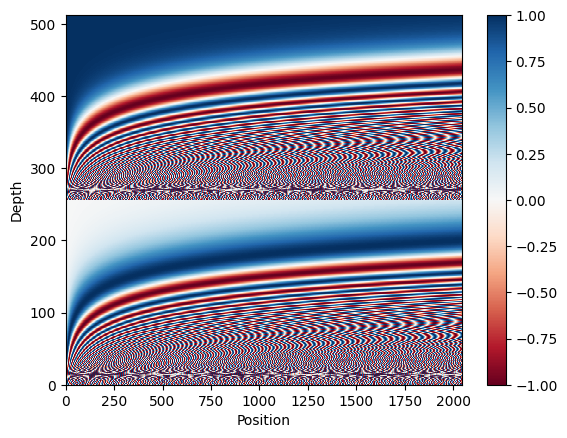

In [18]:
pos_encoding = positional_encoding(length=2048, depth=512)

# Check the shape.
print(pos_encoding.shape)

# Plot the dimensions.
plt.pcolormesh(pos_encoding.numpy().T, cmap='RdBu')
plt.ylabel('Depth')
plt.xlabel('Position')
plt.colorbar()
plt.show()

(0.0, 1.0)

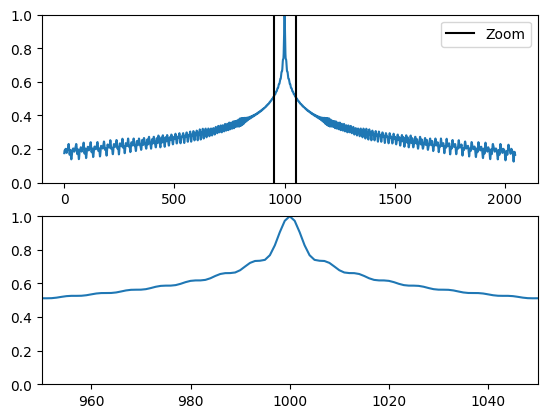

In [19]:
pos_encoding/=tf.norm(pos_encoding, axis=1, keepdims=True)
p = pos_encoding[1000]
dots = tf.einsum('pd,d -> p', pos_encoding, p)
plt.subplot(2,1,1)
plt.plot(dots)
plt.ylim([0,1])
plt.plot([950, 950, float('nan'), 1050, 1050],
         [0,1,float('nan'),0,1], color='k', label='Zoom')
plt.legend()
plt.subplot(2,1,2)
plt.plot(dots)
plt.xlim([950, 1050])
plt.ylim([0,1])

In [20]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = positional_encoding(length=2048, depth=d_model)

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    length = tf.shape(x)[1]
    x = self.embedding(x)
    # This factor sets the relative scale of the embedding and positonal_encoding.
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x = x + self.pos_encoding[tf.newaxis, :length, :]
    return x

In [21]:
# Use the created source_vectorizer and target_vectorizer
# The variables source_vectorizer and target_vectorizer were created by calling the tokenizers function earlier
# Fix: Use vocabulary_size() instead of get_vocabulary_size().numpy()
embed_source = PositionalEmbedding(vocab_size=source_vectorizer.vocabulary_size(), d_model=512)
embed_target = PositionalEmbedding(vocab_size=target_vectorizer.vocabulary_size(), d_model=512)

# Note: The lines below (pt_emb, en_emb) seem to be related to the original example's data structure
# (pt and en variables). These variables ('pt', 'en') do not exist in your current environment
# based on the provided global variables and traceback.
# You might need to adapt the subsequent code that uses pt_emb and en_emb
# to use your actual data variables and the newly created embed_source and embed_target.
# For example, if you intended to test the embedding layers, you would use
# your input and target data batches (from train_ds or val_ds) instead of 'pt' and 'en'.

# If you want to test the embedding layers with sample data:
# Take a sample batch from your training dataset
for inputs, targets in train_ds.take(1):
    # inputs is a dictionary {'encoder_input': ..., 'decoder_input': ...}
    src_batch = inputs['encoder_input']
    tgt_batch = inputs['decoder_input'] # Use decoder_input for target embedding test

    # Apply the embeddings to the sample data
    source_emb = embed_source(src_batch)
    target_emb = embed_target(tgt_batch)

    print("\nShape of source embeddings:", source_emb.shape)
    print("Shape of target embeddings:", target_emb.shape)
    break # Only take one batch for demonstration


Shape of source embeddings: (64, 40, 512)
Shape of target embeddings: (64, 41, 512)


## Add and normalize + The base attention layer

In [22]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

## The cross attention layer

In [23]:
class CrossAttention(BaseAttention):
  def call(self, x, context):
    attn_output, attn_scores = self.mha(
        query=x,
        key=context,
        value=context,
        return_attention_scores=True)

    # Cache the attention scores for plotting later.
    self.last_attn_scores = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

In [24]:
sample_ca = CrossAttention(num_heads=2, key_dim=512)

print(source_emb.shape)
print(target_emb.shape)
print(sample_ca(target_emb, source_emb).shape)

(64, 40, 512)
(64, 41, 512)
(64, 41, 512)


## The global self-attention layer

In [25]:
class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

In [26]:
sample_gsa = GlobalSelfAttention(num_heads=2, key_dim=512)

print(source_emb.shape)
print(sample_gsa(source_emb).shape)

(64, 40, 512)
(64, 40, 512)


## The causal self-attention layer

In [27]:
class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask = True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

In [28]:
sample_csa = CausalSelfAttention(num_heads=2, key_dim=512)

print(target_emb.shape)
print(sample_csa(target_emb).shape)

(64, 41, 512)
(64, 41, 512)


In [29]:
# Take a sample batch from the training dataset to get target sequences
for inputs, targets in train_ds.take(1):
    # Use the decoder_input from the batch as the test sequence
    # This is the input fed into the decoder during training/inference (shifted target tokens)
    test_target_sequence = inputs['decoder_input']
    break # Take only one batch

# We will test the causal self-attention on a single sequence from the batch
# Take the first sequence and keep the batch dimension
test_sequence_single = test_target_sequence[0:1, :]

# Define a prefix length for testing
prefix_length = 3 # Or any small number less than the sequence length

# Apply causal self-attention to the embedded prefix
# Embed the prefix first, then pass to the attention layer
# FIX: Use the embedding layer instance 'embed_target' instead of the tensor 'target_emb'
embedded_prefix = embed_target(test_sequence_single[:, :prefix_length])
out1 = sample_csa(embedded_prefix)

# Apply causal self-attention to the embedded full sequence
# Embed the full sequence, apply attention, then slice the output
# FIX: Use the embedding layer instance 'embed_target' instead of the tensor 'target_emb'
embedded_full_sequence = embed_target(test_sequence_single)
out2_full = sample_csa(embedded_full_sequence)
out2 = out2_full[:, :prefix_length]

# Compare the outputs from processing the prefix vs. processing the full sequence and slicing
# Due to the causal mask, the output for the prefix positions should be identical
# whether you process just the prefix or the full sequence.
comparison_result = tf.reduce_max(abs(out1 - out2)).numpy()

print(f"Maximum absolute difference between prefix output and sliced full sequence output: {comparison_result}")
# A value close to 0 indicates the causal mask is working correctly.

Maximum absolute difference between prefix output and sliced full sequence output: 4.76837158203125e-07


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## The feed forward network

In [30]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    x = self.add([x, self.seq(x)])
    x = self.layer_norm(x)
    return x

In [31]:
sample_ffn = FeedForward(512, 2048)

print(target_emb.shape)
print(sample_ffn(target_emb).shape)

(64, 41, 512)
(64, 41, 512)


## The encoder layer

In [32]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self,*, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x):
    x = self.self_attention(x)
    x = self.ffn(x)
    return x

In [33]:
sample_encoder_layer = EncoderLayer(d_model=512, num_heads=8, dff=2048)

print(source_emb.shape)
print(sample_encoder_layer(source_emb).shape)

(64, 40, 512)
(64, 40, 512)


## The encoder

In [34]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads,
               dff, vocab_size, dropout_rate=0.1):
    super().__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(
        vocab_size=vocab_size, d_model=d_model)

    self.enc_layers = [
        EncoderLayer(d_model=d_model,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, x):
    # `x` is token-IDs shape: (batch, seq_len)
    x = self.pos_embedding(x)  # Shape `(batch_size, seq_len, d_model)`.

    # Add dropout.
    x = self.dropout(x)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x)

    return x  # Shape `(batch_size, seq_len, d_model)`.

In [35]:
# Instantiate the encoder.
sample_encoder = Encoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8500)

# Take one batch from the training dataset to get encoder input
for inputs, targets in train_ds.take(1):
    # inputs is a dictionary {'encoder_input': ..., 'decoder_input': ...}
    # Use the 'encoder_input' from the batch
    encoder_input_sample = inputs['encoder_input']
    break # Take only one batch for demonstration

sample_encoder_output = sample_encoder(encoder_input_sample, training=False)

# Print the shape.
print(encoder_input_sample.shape) # Print shape of the actual input used
print(sample_encoder_output.shape)  # Shape `(batch_size, input_seq_len, d_model)`.

(64, 40)
(64, 40, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention_2' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer_1' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## The decoder layer

In [36]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               d_model,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x, context):
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)

    # Cache the last attention scores for plotting later
    self.last_attn_scores = self.cross_attention.last_attn_scores

    x = self.ffn(x)  # Shape `(batch_size, seq_len, d_model)`.
    return x

In [37]:
sample_decoder_layer = DecoderLayer(d_model=512, num_heads=8, dff=2048)

sample_decoder_layer_output = sample_decoder_layer(
    x=target_emb, context=source_emb)

print(target_emb.shape)
print(source_emb.shape)
print(sample_decoder_layer_output.shape)  # `(batch_size, seq_len, d_model)`

(64, 41, 512)
(64, 40, 512)
(64, 41, 512)


## The decoder

In [38]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(d_model=d_model, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    self.last_attn_scores = None

  def call(self, x, context):
    # `x` is token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # The shape of x is (batch_size, target_seq_len, d_model).
    return x

In [39]:
# Instantiate the decoder.
sample_decoder = Decoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8000)

for inputs, targets in train_ds.take(1):
    # inputs is a dictionary {'encoder_input': ..., 'decoder_input': ...}
    # Use the 'decoder_input' for the decoder's input 'x'
    decoder_input_sample = inputs['decoder_input']
    # Use the output from the sample encoder for the 'context'
    # Need to run the encoder first to get context
    # Assuming sample_encoder was defined and instantiated previously and works correctly
    # If not, instantiate or use the encoder part of your full transformer model
    # For this test, let's re-run the sample encoder or use the transformer's encoder
    # Let's use the same sample_encoder used in the previous cell
    # Ensure encoder_input_sample is available from a previous cell or re-taken here
    encoder_input_sample = inputs['encoder_input']
    context_sample = sample_encoder(encoder_input_sample, training=False) # Use training=False for testing layers

    # Call the sample_decoder with the sample inputs
    output = sample_decoder(
        x=decoder_input_sample, # Use the actual decoder input from the batch
        context=context_sample) # Use the output from the encoder as context

    # Print the shapes.
    print("Shape of decoder_input:", decoder_input_sample.shape)
    print("Shape of encoder_output (context):", context_sample.shape)
    print("Shape of decoder output:", output.shape)  # `(batch_size, seq_len, d_model)`

    # Break after taking the first batch for demonstration
    break

Shape of decoder_input: (64, 41)
Shape of encoder_output (context): (64, 40, 512)
Shape of decoder output: (64, 41, 512)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'causal_self_attention_2' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'decoder_layer_1' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [40]:
sample_decoder.last_attn_scores.shape  # (batch, heads, target_seq, input_seq)

TensorShape([64, 8, 41, 40])

# The Transformer

In [41]:
class Transformer(tf.keras.Model):
  def __init__(self, *, num_layers, d_model, num_heads, dff,
               input_vocab_size, target_vocab_size, dropout_rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=input_vocab_size,
                           dropout_rate=dropout_rate)

    self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=target_vocab_size,
                           dropout_rate=dropout_rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  # Accept inputs as a dictionary
  def call(self, inputs):
    context = inputs['encoder_input'] # Unpack the dictionary here
    x  = inputs['decoder_input']     # Unpack the dictionary here

    context = self.encoder(context)  # (batch_size, context_len, d_model)

    x = self.decoder(x, context)  # (batch_size, target_len, d_model)

    # Final linear layer output.
    logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

    try:
      # Drop the keras mask, so it doesn't scale the losses/metrics.
      # b/250038731
      del logits._keras_mask
    except AttributeError:
      pass

    # Return the final output (logits)
    return logits

## Hyperparameters


In [42]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8
dropout_rate = 0.1

## Make model

In [43]:
transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=len(source_vectorizer.get_vocabulary()),
    target_vocab_size=len(target_vectorizer.get_vocabulary()),
    dropout_rate=dropout_rate)

In [44]:
# Take one batch from the training dataset to test the transformer model
for inputs, targets in train_ds.take(1):
    # inputs is a dictionary {'encoder_input': ..., 'decoder_input': ...}
    # We can pass this dictionary directly to the transformer's call method

    output = transformer(inputs)

    # You can now print the shapes of the inputs and the output
    # inputs is a dictionary, so print shapes of its values
    print("Shape of encoder_input:", inputs['encoder_input'].shape)
    print("Shape of decoder_input:", inputs['decoder_input'].shape)
    print("Shape of model output:", output.shape)

    # Break after taking the first batch to avoid processing the whole dataset
    break

print()
# The transformer summary doesn't need data input, so it can be called directly
transformer.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention_6' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer_5' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'causal_self_attention_6' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the 

Shape of encoder_input: (64, 40)
Shape of decoder_input: (64, 41)
Shape of model output: (64, 41, 3174)



Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (Encoder)             │ ?                      │     2,993,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Decoder)             │ ?                      │     5,156,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (64, 41, 3174)         │       409,446 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,558,950 (32.65 MB)

 Trainable params: 8,558,950 (32.65 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
attn_scores = transformer.decoder.dec_layers[-1].last_attn_scores
print(attn_scores.shape)  # (batch, heads, target_seq, input_seq)

(64, 8, 41, 40)


# Training

## Set up the optimizer

In [46]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [47]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

Text(0.5, 0, 'Train Step')

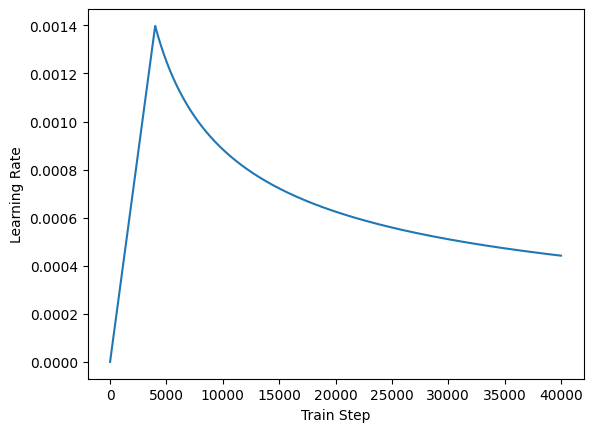

In [48]:
plt.plot(learning_rate(tf.range(40000, dtype=tf.float32)))
plt.ylabel('Learning Rate')
plt.xlabel('Train Step')

## Set up the loss and metrics

In [49]:
def masked_loss(label, pred):
  mask = label != 0
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')
  loss = loss_object(label, pred)

  mask = tf.cast(mask, dtype=loss.dtype)
  loss *= mask

  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss


def masked_accuracy(label, pred):
  pred = tf.argmax(pred, axis=2)
  label = tf.cast(label, pred.dtype)
  match = label == pred

  mask = label != 0

  match = match & mask

  match = tf.cast(match, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  return tf.reduce_sum(match)/tf.reduce_sum(mask)

## Train the model

In [50]:
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy])

In [51]:
transformer.fit(train_ds,
                epochs=10,
                validation_data=val_ds)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 75s 444ms/step - loss: 7.9528 - masked_accuracy: 0.0454 - val_loss: 7.4677 - val_masked_accuracy: 0.1564
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 7.4015 - masked_accuracy: 0.1777 - val_loss: 7.0999 - val_masked_accuracy: 0.2100
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 7.0178 - masked_accuracy: 0.2020 - val_loss: 6.6351 - val_masked_accuracy: 0.2167
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 6.4878 - masked_accuracy: 0.2126 - val_loss: 6.0663 - val_masked_accuracy: 0.2425
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 5.8935 - masked_accuracy: 0.2414 - val_loss: 5.5487 - val_masked_accuracy: 0.2833
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 5.3684 - masked_accuracy: 0.2947 - val_loss: 5.0204 - val_masked_accuracy: 0.3548
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 4.7279 - masked_accuracy: 0.3816 - val_loss: 4.3768 - val_masked_accuracy: 0.4259
Epoch 8/10


# Run inference

## Run inference claude

### Rev

In [54]:
MAX_TOKENS = 42

class Translator(tf.Module):
  def __init__(self, tokenizers, transformer):
    self.tokenizers = tokenizers
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):
    # The input sentence is Portuguese, hence adding the `[START]` and `[END]` tokens.
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizers.pt.tokenize(sentence).to_tensor()

    encoder_input = sentence

    # As the output language is English, initialize the output with the
    # English `[START]` token.
    start_end = self.tokenizers.en.tokenize([''])[0]
    start = start_end[0][tf.newaxis]
    end = start_end[1][tf.newaxis]

    # `tf.TensorArray` is required here (instead of a Python list), so that the
    # dynamic-loop can be traced by `tf.function`.
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      output = tf.transpose(output_array.stack())
      predictions = self.transformer([encoder_input, output], training=False)

      # Select the last token from the `seq_len` dimension.
      predictions = predictions[:, -1:, :]  # Shape `(batch_size, 1, vocab_size)`.

      predicted_id = tf.argmax(predictions, axis=-1)

      # Concatenate the `predicted_id` to the output which is given to the
      # decoder as its input.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack())
    # The output shape is `(1, tokens)`.
    text = tokenizers.en.detokenize(output)[0]  # Shape: `()`.

    tokens = tokenizers.en.lookup(output)[0]

    # `tf.function` prevents us from using the attention_weights that were
    # calculated on the last iteration of the loop.
    # So, recalculate them outside the loop.
    self.transformer([encoder_input, output[:,:-1]], training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights

In [56]:
translator = Translator(tokenizers, transformer)

In [57]:
def print_translation(sentence, tokens, ground_truth):
  print(f'{"Input:":15s}: {sentence}')
  print(f'{"Prediction":15s}: {tokens.numpy().decode("utf-8")}')
  print(f'{"Ground truth":15s}: {ground_truth}')

In [58]:
sentence = df.loc[0, src_col]
ground_truth = df.loc[0, dst_col]

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

AttributeError: 'function' object has no attribute 'pt'

### REV1

In [98]:
class Translator(tf.Module):
  def __init__(self, tokenizers, transformer):
    self.tokenizers = tokenizers
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):
    # The input sentence is Portuguese, hence adding the `[START]` and `[END]` tokens.
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizers.pt.tokenize(sentence).to_tensor()

    encoder_input = sentence

    # As the output language is English, initialize the output with the
    # English `[START]` token.
    start_end = self.tokenizers.en.tokenize([''])[0]
    start = start_end[0][tf.newaxis]
    end = start_end[1][tf.newaxis]

    # `tf.TensorArray` is required here (instead of a Python list), so that the
    # dynamic-loop can be traced by `tf.function`.
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      output = tf.transpose(output_array.stack())
      predictions = self.transformer([encoder_input, output], training=False)

      # Select the last token from the `seq_len` dimension.
      predictions = predictions[:, -1:, :]  # Shape `(batch_size, 1, vocab_size)`.

      predicted_id = tf.argmax(predictions, axis=-1)

      # Concatenate the `predicted_id` to the output which is given to the
      # decoder as its input.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack())
    # The output shape is `(1, tokens)`.
    text = tokenizers.en.detokenize(output)[0]  # Shape: `()`.

    tokens = tokenizers.en.lookup(output)[0]

    # `tf.function` prevents us from using the attention_weights that were
    # calculated on the last iteration of the loop.
    # So, recalculate them outside the loop.
    self.transformer([encoder_input, output[:,:-1]], training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights

In [99]:
def print_translation(sentence, translated_text, ground_truth):
  """Prints the input sentence, translated text, and ground truth."""
  print(f'{"Input:":15s}: {sentence}')
  # Use the directly translated string output
  print(f'{"Prediction":15s}: {translated_text}')
  print(f'{"Ground truth":15s}: {ground_truth}')

In [100]:
translator = Translator(tokenizers, transformer)

In [101]:
sentence = df.loc[0, src_col]
ground_truth = df.loc[0, dst_col]

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

AttributeError: 'function' object has no attribute 'pt'

## Create attention plots

In [ ]:
def plot_attention_head(in_tokens, translated_tokens, attention):
    # Assuming translated_tokens are token IDs, shape (1, seq_len)
    # Get the string representation for plotting
    target_vocab = target_vectorizer.get_vocabulary() # Access the target vectorizer from the outer scope

    # Handle cases where translated_tokens might be just the start token or empty
    if tf.is_tensor(translated_tokens) and tf.shape(translated_tokens)[1] > 1:
        # Map token IDs back to strings, starting from the second token (index 1)
        translated_token_strings = [target_vocab[token_id] for token_id in translated_tokens[0, 1:].numpy()]
    else:
        # If sequence length is 1 or less, there are no translated tokens besides possibly <sos>
        translated_token_strings = [] # Plotting axis will be empty


    ax = plt.gca()
    # Ensure attention shape matches the number of input and output tokens for plotting
    # Attention shape from Transformer is typically (num_heads, target_seq_len, source_seq_len)
    # For a single head (passed as 'head' here), it's (target_seq_len, source_seq_len)
    # We need to slice attention to match the actual translated tokens (excluding <sos>)
    # The attention weights correspond to the decoder's output length.
    # The decoder output length for the plot should match the length of translated_token_strings
    # Attention has shape (target_seq_len, source_seq_len).
    # translated_token_strings corresponds to the output tokens *after* <sos>, which are at indices 1 to end in the original decoder output sequence.
    # The attention slice needs to match the length of the target sequence *that was fed into the decoder during the last step of generation*.
    # The attention weights stored are for the call to the decoder with `tokens[:, :-1]` as input.
    # This sequence `tokens[:, :-1]` has length `len(decoded_tokens) + 1` (including sos).
    # The attention weights for `tokens[:, :-1]` will have shape `(len(decoded_tokens)+1, source_seq_len)`.
    # We want to plot attention corresponding to the `decoded_tokens` (excluding sos/eos).
    # This corresponds to the attention weights from index 1 onwards.

    # Get the number of translated tokens *excluding* the start token (if present)
    num_translated_for_plot = len(translated_token_strings)

    # Slice the attention matrix to match the number of translated tokens being plotted
    # The attention matrix has shape (target_seq_len_used_in_decode, source_seq_len)
    # The sequence fed to decoder to get the LAST prediction was `tokens[:, :-1]`
    # The stored attention has shape (length_of_tokens_excluding_last_one, src_seq_len)
    # This length is len(decoded_tokens) + 1 (the <sos> token + translated tokens).
    # We need to plot the attention weights corresponding to the *translated* tokens, which are at indices 1 onwards in the target sequence.
    # So, slice attention from index 1 along the target sequence dimension.
    if attention is not None and attention.shape[0] >= num_translated_for_plot:
         # Slice the attention matrix to match the number of translated tokens being plotted
         # attention has shape (target_seq_len_decoder_input, source_seq_len)
         # The number of rows needed is the number of translated tokens + 1 (for <sos>)
         # But we only plot the translated tokens themselves (excluding <sos>)
         # So we plot the attention from the 1st row onwards (corresponding to the first translated token)
         # The number of rows should be len(translated_token_strings)
         plottable_attention = attention[:num_translated_for_plot, :] # Take rows corresponding to translated tokens
         # Ensure the number of columns matches the input tokens plotted
         if plottable_attention.shape[1] != len(in_tokens):
             print(f"Warning: Attention columns ({plottable_attention.shape[1]}) do not match input tokens ({len(in_tokens)}) for plotting.")
             # Adjust if possible or skip plotting
             plottable_attention = plottable_attention[:, :len(in_tokens)] # Trim if too long

         ax.matshow(plottable_attention)

         # Use the number of tokens (strings) for xticks and yticks
         ax.set_xticks(range(len(in_tokens)))
         ax.set_yticks(range(len(translated_token_strings))) # Use length of string list for yticks

         # Assuming in_tokens are already strings or can be converted to strings
         ax.set_xticklabels(in_tokens, rotation=90)
         ax.set_yticklabels(translated_token_strings)
    else:
        # Handle case where attention is None or shape is incorrect for slicing
        print("Warning: Attention weights are not available or have incorrect shape for plotting.")
        ax.set_title("Attention weights not available/plottable")
        ax.set_xticks([])
        ax.set_yticks([])

# Create attention plots

In [ ]:
def plot_attention_head(in_tokens, translated_tokens, attention):
  # The model didn't generate `<START>` in the output. Skip it.
  # Check if translated_tokens is a tensor and has more than one element before slicing
  if tf.is_tensor(translated_tokens) and tf.shape(translated_tokens)[1] > 1:
      # Assuming translated_tokens are token IDs
      # You need to get the string representation for plotting
      # translated_tokens[0] is the batch dimension
      target_vocab = target_vectorizer.get_vocabulary() # Access the target vectorizer from the outer scope
      translated_token_strings = [target_vocab[token_id] for token_id in translated_tokens[0, 1:].numpy()]
  else:
      # Handle cases where translated_tokens might be empty or just the start token
      translated_token_strings = []


  ax = plt.gca()
  ax.matshow(attention)
  # Use the number of tokens (strings) for xticks and yticks
  ax.set_xticks(range(len(in_tokens)))
  ax.set_yticks(range(len(translated_token_strings)))

  # Assuming in_tokens are already strings or can be converted to strings
  ax.set_xticklabels(in_tokens, rotation=90)
  ax.set_yticklabels(translated_token_strings)

In [ ]:
# Pass the source_vectorizer to the plot_attention_weights function
def plot_attention_weights(sentence, translated_tokens, attention_heads, source_vectorizer, target_vectorizer):
  # Use the source_vectorizer to convert the input sentence (string) to token IDs
  # Then get the vocabulary from the source_vectorizer to get the string tokens for plotting
  input_token_ids = source_vectorizer([sentence]) # Gives shape (1, seq_len)
  source_vocab = source_vectorizer.get_vocabulary() # Access the source vectorizer from the outer scope
  # Map token IDs back to strings for plotting, excluding padding (usually 0)
  # input_token_ids[0] is the batch dimension
  in_tokens = [source_vocab[token_id] for token_id in input_token_ids[0].numpy() if token_id != 0]


  fig = plt.figure(figsize=(16, 8))

  for h, head in enumerate(attention_heads):
    ax = fig.add_subplot(2, 4, h+1)

    # Pass the string tokens for input and the token IDs for translated to plot_attention_head
    plot_attention_head(in_tokens, translated_tokens, head)

    ax.set_xlabel(f'Head {h+1}')

  plt.tight_layout()
  plt.show()

In [ ]:
sentence = df.loc[0, 'id']
ground_truth = df.loc[0, 'bkl']

translated_text, translated_tokens, attention_weights = translator(tf.constant(sentence))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

In [ ]:
# plot_attention_weights(sentence,
#                        translated_tokens, # Pass the translated token IDs
#                        attention_weights[0], # Pass the attention weights for the first example
#                        source_vectorizer, # Pass the source vectorizer
#                        target_vectorizer # Pass the target vectorizer
#                        )

--- Contoh Penerjemahan 1 ---
Input:         : Bunga dihalaman rumah dibersihkan semua oleh tukang rumput
Prediction     : betul betanak betanak lidah caknyo caknyo caknyo ngebajak betanak ngebahas berangberang dampak dampak kartuos omongan didik menit bekurang incekincekan bekurang incekincekan potongpotong ngehubungi ngerokok berembuk potongpotong bahanbahannyo uang telambek nyetrikanyo fokus rokok raib jamur setelah potongpotong potongpotong potongpotong incekincekan bahanbahannyo keladi dampak
Ground truth   : Bungo dilaman rumah di babat galo dekek tukang rumput


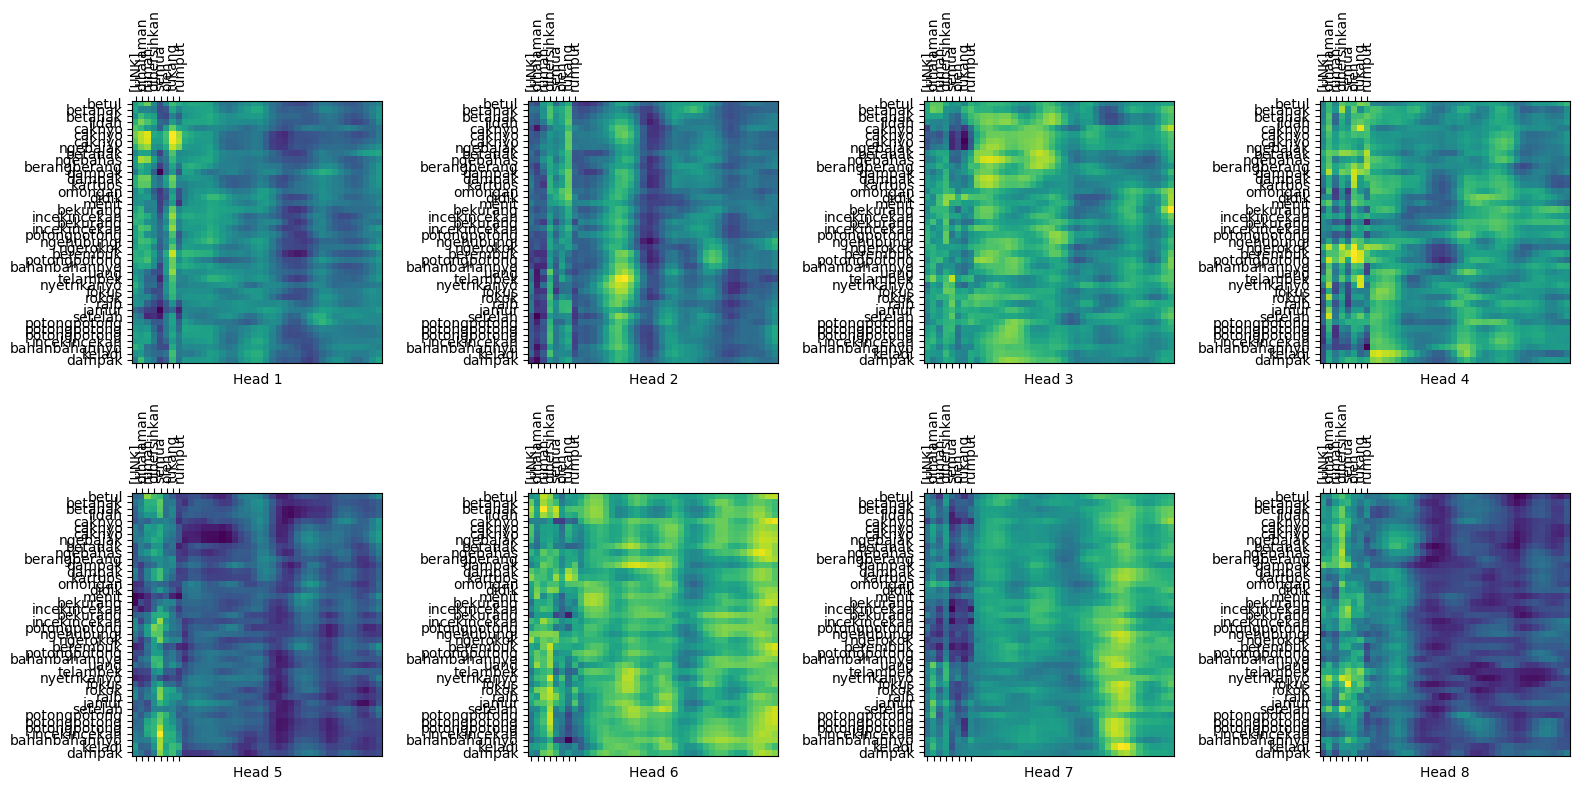

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 2 ---
Input:         : Bapak ini sangat suka dengan sayur perut sapi
Prediction     : betul betanak betanak lidah caknyo caknyo caknyo ngebajak betanak ngebahas berangberang dampak dampak kartuos omongan didik menit bekurang incekincekan bekurang incekincekan potongpotong ngehubungi ngerokok berembuk potongpotong incekincekan nyetrikanyo telambek nyetrikanyo fokus rokok raib jamur setelah potongpotong potongpotong potongpotong incekincekan bahanbahannyo keladi dampak
Ground truth   : Gaek lanang iko suko nian gulai sapi babat


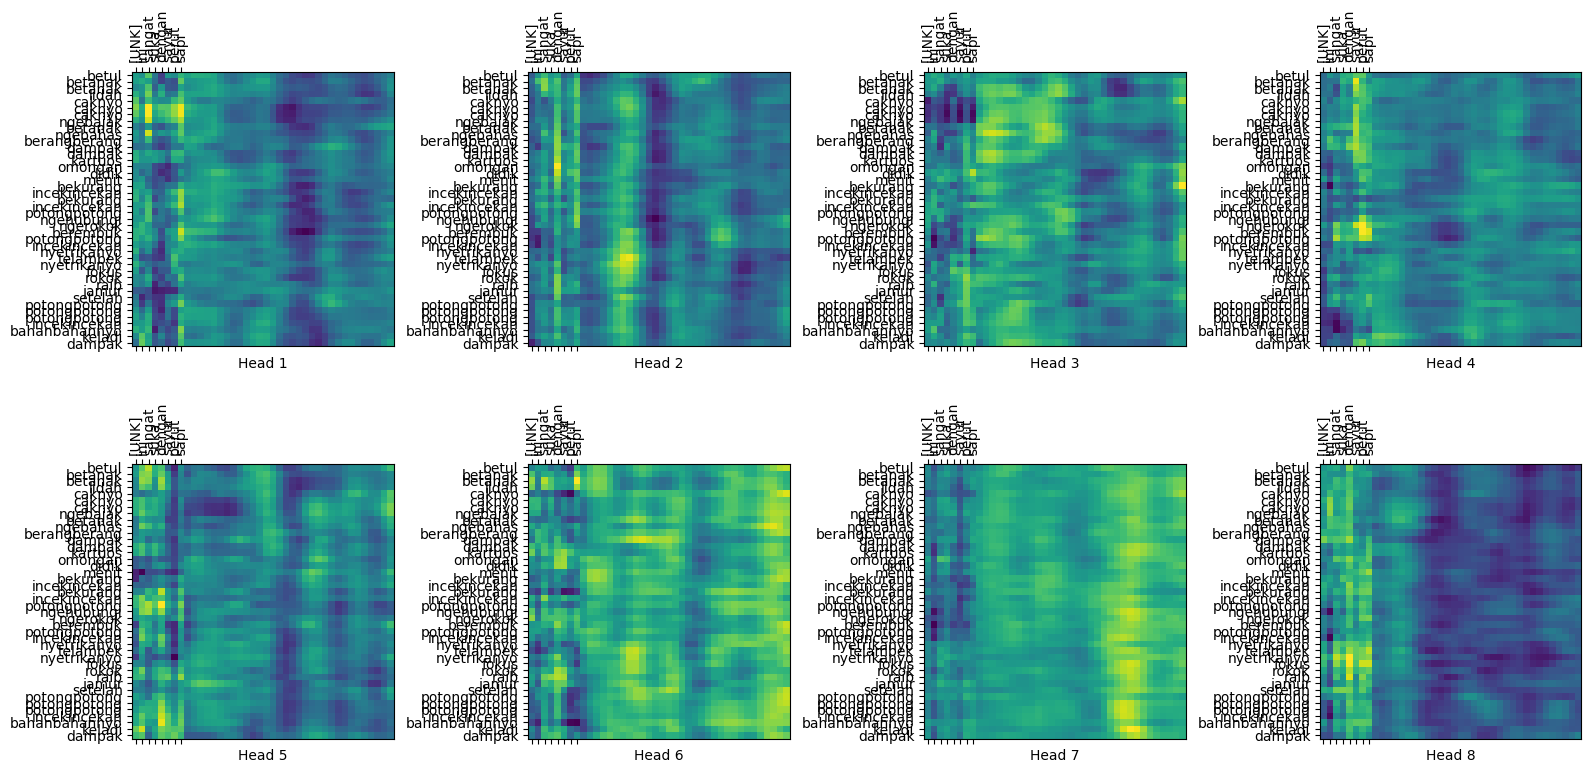

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 3 ---
Input:         : Dia menikahkan anak nya sangat besar-besaran
Prediction     : betul betanak betanak lidah caknyo caknyo caknyo betanak betanak ngebahas berangberang dampak dampak kartuos omongan didik menit bekurang incekincekan bekurang incekincekan potongpotong ngehubungi ngerokok berembuk potongpotong incekincekan nyetrikanyo telambek nyetrikanyo fokus rokok raib jamur setelah potongpotong potongpotong potongpotong incekincekan bahanbahannyo keladi dampak
Ground truth   : Nyo nikahi anak nyo berarat-arat nian


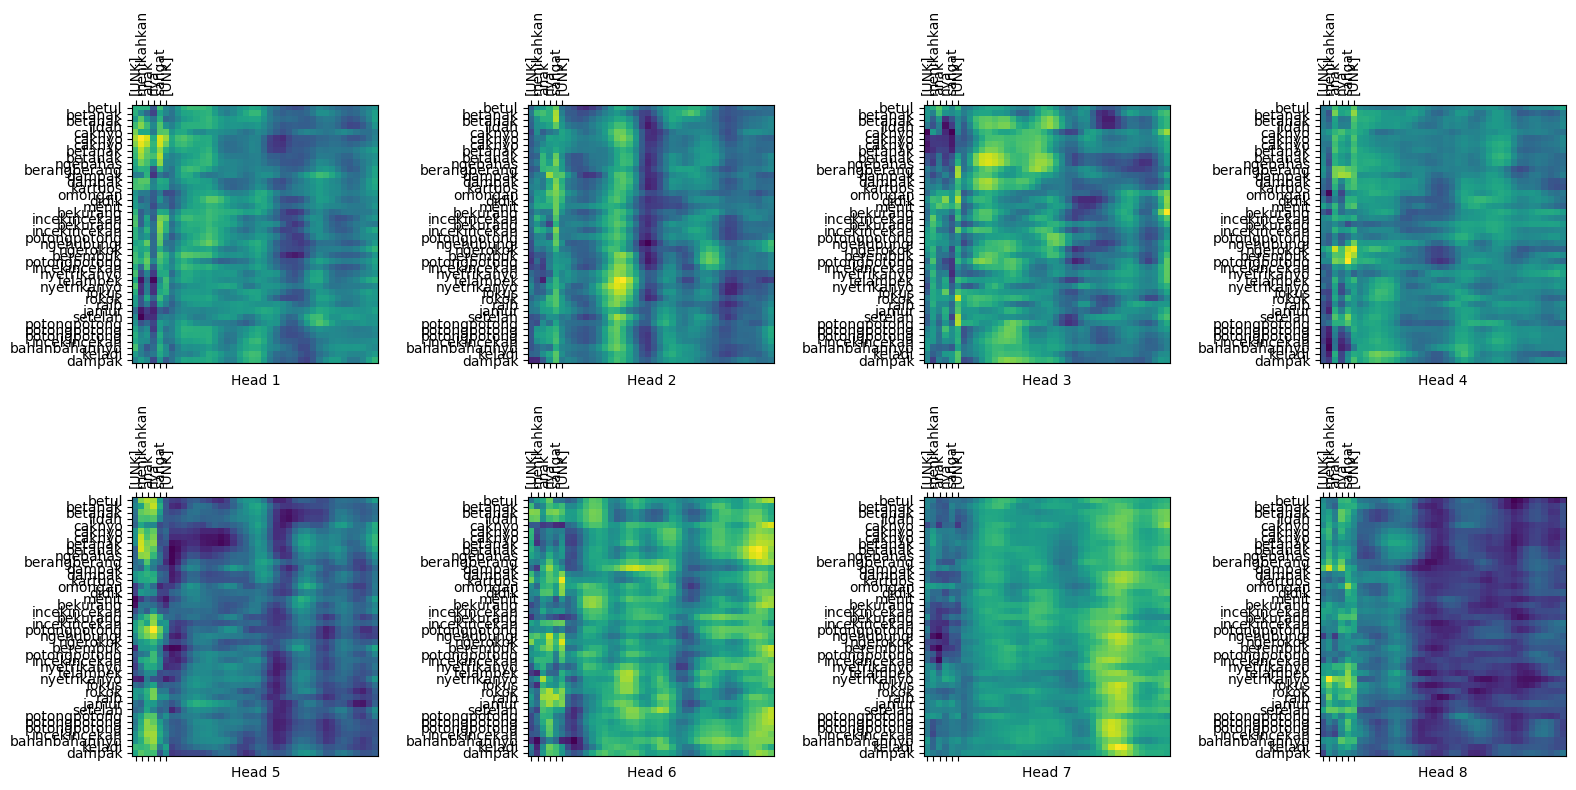

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 4 ---
Input:         : Sakitnya sekarang sudah bertambah parah
Prediction     : betul betanak betanak lidah caknyo caknyo caknyo betanak betanak ngebahas berangberang dampak dampak kartuos omongan didik menit bekurang incekincekan bekurang incekincekan potongpotong ngehubungi ngerokok berembuk potongpotong incekincekan nyetrikanyo telambek nyetrikanyo fokus rokok raib jamur setelah potongpotong potongpotong potongpotong incekincekan bahanbahannyo keladi dampak
Ground truth   : Sakitnyo kini lah bertambah arat


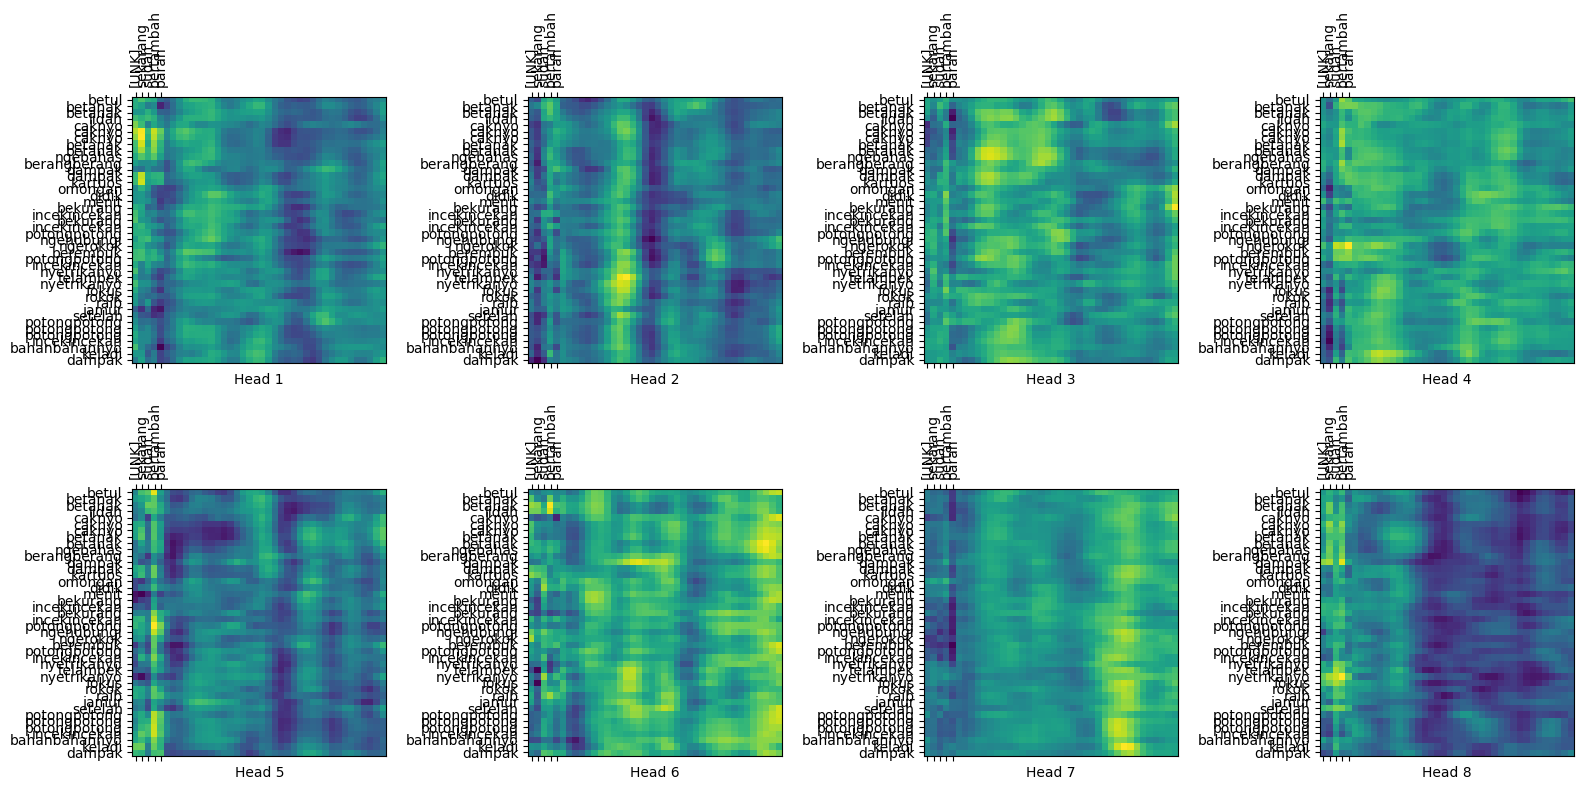

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/lo

--- Contoh Penerjemahan 5 ---
Input:         : Sudah sebesar ini saya belum juga menghapal perkalian
Prediction     : betul betanak betanak lidah caknyo caknyo caknyo ngebajak betanak ngebahas berangberang dampak dampak kartuos omongan didik menit bekurang incekincekan bekurang incekincekan potongpotong ngehubungi ngerokok berembuk potongpotong incekincekan nyetrikanyo telambek nyetrikanyo fokus rokok raib jamur setelah potongpotong potongpotong potongpotong incekincekan bahanbahannyo keladi dampak
Ground truth   : La segedang iko ambo belum jugo apal perkalian


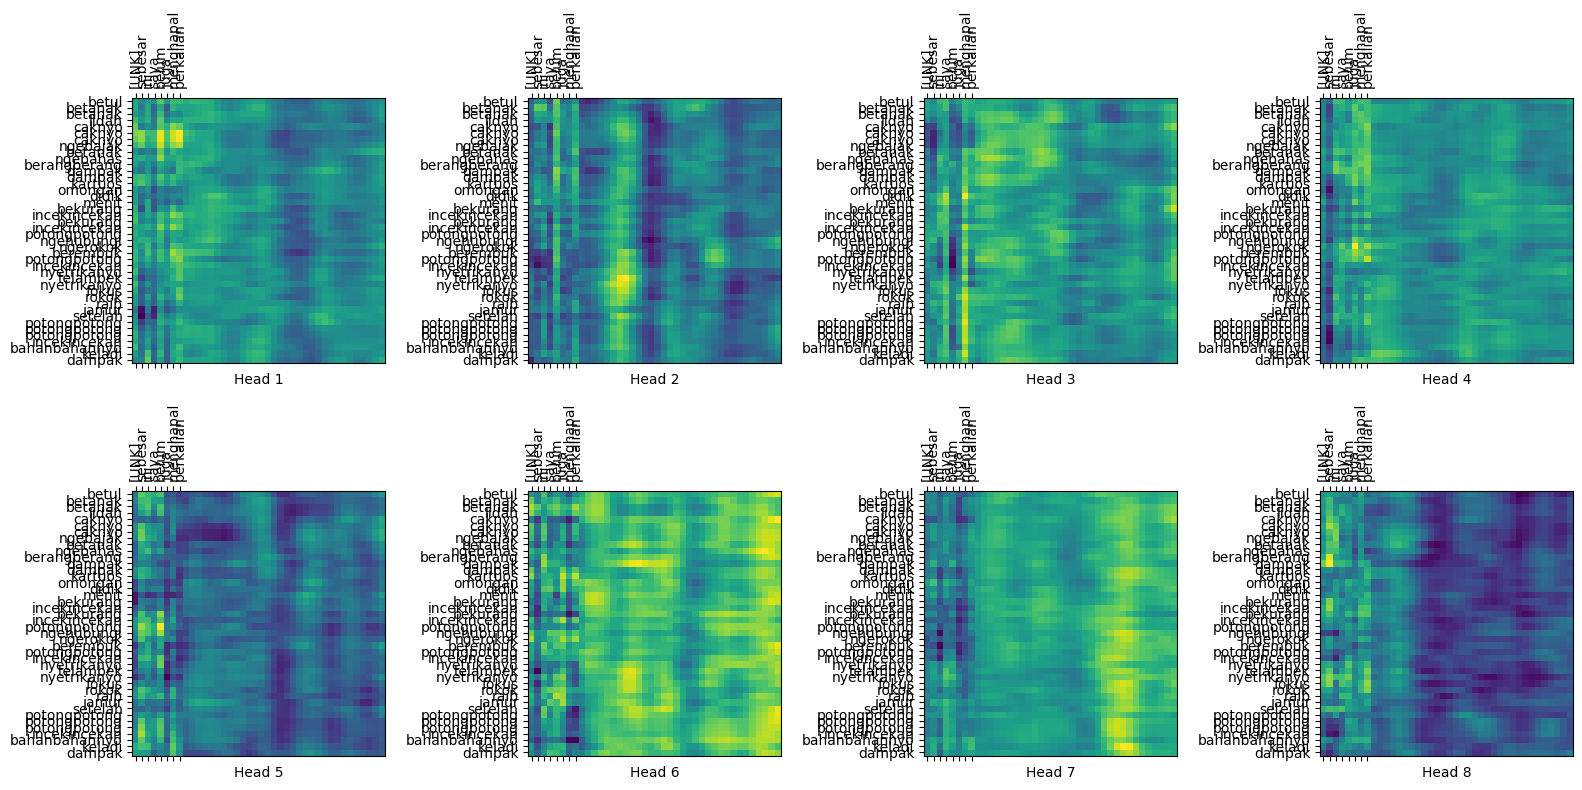

In [ ]:
# In the loop for multiple examples:
num_examples_to_translate = 5 # Ubah angka ini sesuai kebutuhan Anda

for i in range(num_examples_to_translate):
    sentence = df.loc[i, 'id']
    ground_truth = df.loc[i, 'bkl']

    translated_text, translated_tokens, attention_weights = translator(
        tf.constant(sentence))

    print(f"--- Contoh Penerjemahan {i+1} ---")
    print_translation(sentence, translated_text, ground_truth)

    # Pass the necessary arguments to plot_attention_weights
    plot_attention_weights(sentence,
                           translated_tokens, # Pass the translated token IDs
                           attention_weights[0], # Pass the attention weights for the current example
                           source_vectorizer, # Pass the source vectorizer
                           target_vectorizer # Pass the target vectorizer
                           )

    print("\n") # Beri spasi antar contoh

# Evaluation with BLEU

In [ ]:
# def evaluate(input_sentence, transformer, source_vectorizer, target_vectorizer, max_length=40):
#     # Tokenisasi input
#     input_tensor = source_vectorizer([input_sentence])  # shape (1, seq_len)

#     # Inisialisasi decoder dengan token <start>
#     start_token = target_vectorizer([''])[0][0].numpy()  # asumsi token pertama adalah <start>
#     decoder_input = tf.expand_dims([start_token], 0)  # shape (1, 1)

#     output = []

#     for i in range(max_length):
#         predictions = transformer([input_tensor, decoder_input], training=False)
#         predicted_id = tf.argmax(predictions[:, -1, :], axis=-1).numpy()[0]
#         output.append(predicted_id)

#         # stop jika prediksi token <end> (di sini kita anggap token padding = 0)
#         if predicted_id == 0:
#             break

#         decoder_input = tf.concat([decoder_input, [[predicted_id]]], axis=-1)

#     # Ubah output token ke string
#     id_to_token = dict(enumerate(target_vectorizer.get_vocabulary()))
#     decoded_tokens = [id_to_token[i] for i in output if i != 0]
#     return ' '.join(decoded_tokens)


In [ ]:
# from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
# from nltk.tokenize import word_tokenize
# import nltk
# nltk.download('punkt')
# nltk.download('punkt_tab')

# def evaluate_bleu(
#     model,
#     source_texts,
#     reference_texts,
#     source_vectorizer,
#     target_vectorizer,
#     max_samples=100,
#     max_length=40
# ):
#     hypotheses = []
#     references = []
#     smoother = SmoothingFunction().method4

#     for src, ref in zip(source_texts[:max_samples], reference_texts[:max_samples]):
#         pred = evaluate(src, model, source_vectorizer, target_vectorizer, max_length)
#         hypotheses.append(word_tokenize(pred))
#         references.append([word_tokenize(ref)])

#     score = corpus_bleu(references, hypotheses, smoothing_function=smoother)
#     return score

In [ ]:
# def evaluate(input_sentence, transformer, source_vectorizer, target_vectorizer, max_length=40):
#     # Tokenisasi input
#     input_tensor = source_vectorizer([input_sentence])  # shape (1, seq_len)

#     # Inisialisasi decoder dengan token <start>
#     # Find the ID of the '<sos>' token which is used as the start token in preparation
#     # Use argmax to get the ID of the token that results from vectorizing ['<sos>']
#     start_token = tf.argmax(target_vectorizer(['<sos>'])[0]).numpy()
#     decoder_input = tf.expand_dims([start_token], 0)  # shape (1, 1)

#     output = []

#     for i in range(max_length):
#         # Pass inputs as a dictionary
#         predictions = transformer({'encoder_input': input_tensor, 'decoder_input': decoder_input}, training=False)
#         predicted_id = tf.argmax(predictions[:, -1, :], axis=-1).numpy()[0]
#         output.append(predicted_id)

#         # stop jika prediksi token <end>
#         # Find the ID of the '<eos>' token
#         end_token = tf.argmax(target_vectorizer(['<eos>'])[0]).numpy()
#         if predicted_id == end_token:
#             break

#         decoder_input = tf.concat([decoder_input, [[predicted_id]]], axis=-1)

#     # Ubah output token ke string
#     id_to_token = dict(enumerate(target_vectorizer.get_vocabulary()))
#     # Exclude the padding token (usually 0), and start/end tokens from the output string
#     decoded_tokens = [id_to_token[i] for i in output if i != 0 and i != start_token and i != end_token]
#     return ' '.join(decoded_tokens)

In [ ]:
# # Contoh penggunaan

# bleu = evaluate_bleu(
#     model=transformer,
#     source_texts=val_src,
#     reference_texts=val_tgt,
#     source_vectorizer=source_vectorizer,
#     target_vectorizer=target_vectorizer,
#     max_samples=5
# )

# print(f"BLEU Score: {bleu:.4f}")